# FASE 1 - Paso 1: Análisis Exploratorio de TASS

**Objetivo**: Cargar el dataset TASS, crear splits, visualizar distribución y analizar características.

**Dataset**: TASS (Twitter Analysis for Spanish Sentiment)
- **Archivos**: `cr-tass.csv` (train), `cr1-tass.csv` (test)
- **Clases**: N (Negativo), NEU (Neutral), P (Positivo)
- **Tarea**: Análisis de sentimientos (clasificación 3 clases)

**✅ Este notebook se ejecuta LOCAL (sin GPU)**

---

## 1. Importar librerías

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Cargar datasets TASS

In [20]:
# Rutas de los datasets (ajusta si es necesario)
TRAIN_PATH = '../datasets-taller/datasets-taller/TASS/cr-tass.csv'
TEST_PATH = '../datasets-taller/datasets-taller/TASS/cr1-tass.csv'

# Cargar datasets
print("📂 Cargando datasets TASS...")
try:
    df_train_full = pd.read_csv(TRAIN_PATH)
    df_test = pd.read_csv(TEST_PATH)
    print(f"\n✅ Datasets cargados exitosamente:")
    print(f"   - Train completo: {len(df_train_full)} muestras")
    print(f"   - Test: {len(df_test)} muestras")
except FileNotFoundError as e:
    print(f"\n❌ Error: No se encontraron los archivos. Verifica las rutas.")
    print(f"   {e}")
    raise

print(f"\n📊 Columnas del dataset:")
print(df_train_full.columns.tolist())

📂 Cargando datasets TASS...

✅ Datasets cargados exitosamente:
   - Train completo: 4802 muestras
   - Test: 2443 muestras

📊 Columnas del dataset:
['id', 'sentencia original', 'label']


## 3. Inspeccionar primeras filas

In [21]:
print("🔍 Primeras 5 muestras del train:")
display(df_train_full.head())

print("\n🔍 Últimas 5 muestras del train:")
display(df_train_full.tail())

🔍 Primeras 5 muestras del train:


,id,sentencia original,label
0,818942405281980417,No mames este pinche dolor que pedo? ya mejor ...,N
1,818963123646373892,"@leomall2018 Según yo era como aviso, pero aho...",NEU
2,818998133694697472,@benshorts a juzgar por mis comportamientos au...,N
3,818822556090105857,#BuenosDias mundo Twittero ya desperté y estoy...,P
4,818993011514372098,No pude resolver el rompecabezas en Los rios d...,N



🔍 Últimas 5 muestras del train:


,id,sentencia original,label
4797,771207534342320128,Si andan haciendo eso mejor se quedaran callad...,N
4798,757247192050446337,Mi familia va para la playa y yo por irrespons...,NEU
4799,756354568003457024,"@donovanrp excelente, cuando me den el carro l...",P
4800,795661212101017601,Llevo más de una semana lesionada,N
4801,806270461080375296,Nadie quiere ir a tomar café conmigo,N


## 4. Explorar estructura del dataset

In [22]:
# Información general
print("📋 Información del dataset TRAIN:")
print(df_train_full.info())

print("\n📋 Información del dataset TEST:")
print(df_test.info())

# Verificar valores nulos
print("\n🔍 Valores nulos en TRAIN:")
print(df_train_full.isnull().sum())

print("\n🔍 Valores nulos en TEST:")
print(df_test.isnull().sum())

📋 Información del dataset TRAIN:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4802 entries, 0 to 4801
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  4802 non-null   object
 1   sentencia original  4802 non-null   object
 2   label               4802 non-null   object
dtypes: object(3)
memory usage: 112.7+ KB
None

📋 Información del dataset TEST:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443 entries, 0 to 2442
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  2443 non-null   object
 1   sentencia original  2443 non-null   object
 2   label               2443 non-null   object
dtypes: object(3)
memory usage: 57.4+ KB
None

🔍 Valores nulos en TRAIN:
id                    0
sentencia original    0
label                 0
dtype: int64

🔍 Valores nulos en TEST:
id         

## 5. Identificar y estandarizar columnas

**⚠️ IMPORTANTE**: Los datasets TASS pueden tener diferentes nombres de columnas.
Necesitamos identificar cuál es la columna de texto y cuál de etiquetas.

Posibles nombres:
- Texto: `text`, `tweet`, `content`, `mensaje`
- Etiqueta: `label`, `sentiment`, `polarity`, `sentimiento`

In [23]:
# Mostrar todas las columnas y sus tipos
print("📊 Estructura de columnas:")
for col in df_train_full.columns:
    print(f"   - {col}: {df_train_full[col].dtype} | Ejemplo: {df_train_full[col].iloc[0][:50] if isinstance(df_train_full[col].iloc[0], str) else df_train_full[col].iloc[0]}")

# TODO: Ajusta estos nombres según tu dataset
# Descomenta y modifica según sea necesario:

# Opción 1: Si las columnas ya son 'text' y 'label'
# TEXT_COL = 'text'
# LABEL_COL = 'label'

# Opción 2: Si tienen otros nombres, renombrar
# df_train_full = df_train_full.rename(columns={'tweet': 'text', 'sentiment': 'label'})
# df_test = df_test.rename(columns={'tweet': 'text', 'sentiment': 'label'})
# TEXT_COL = 'text'
# LABEL_COL = 'label'

print("\n⚠️ ACCIÓN REQUERIDA: Define TEXT_COL y LABEL_COL según tu dataset")

📊 Estructura de columnas:
   - id: object | Ejemplo: 818942405281980417
   - sentencia original: object | Ejemplo: No mames este pinche dolor que pedo? ya mejor llév
   - label: object | Ejemplo: N

⚠️ ACCIÓN REQUERIDA: Define TEXT_COL y LABEL_COL según tu dataset


In [24]:
# ✏️ CONFIGURACIÓN: Identificar columnas correctas
print("📊 Columnas disponibles en el dataset:")
print(df_train_full.columns.tolist())
print("\n🔍 Análisis de columnas:")

# Mostrar primeras filas de cada columna para identificarlas
for col in df_train_full.columns:
    ejemplo = df_train_full[col].iloc[0]
    tipo = df_train_full[col].dtype
    print(f"\n   Columna: '{col}'")
    print(f"   Tipo: {tipo}")
    print(f"   Ejemplo: {str(ejemplo)[:80]}{'...' if len(str(ejemplo)) > 80 else ''}")
    print(f"   Valores únicos: {df_train_full[col].nunique()}")

# Intentar detectar automáticamente las columnas
print("\n" + "="*70)
print("🤖 Intentando detectar columnas automáticamente...")

# Detectar columna de texto (la que tenga strings largos)
text_candidates = []
for col in df_train_full.columns:
    if df_train_full[col].dtype == 'object':
        avg_len = df_train_full[col].astype(str).str.len().mean()
        if avg_len > 20:  # Probablemente texto
            text_candidates.append((col, avg_len))

# Detectar columna de etiqueta (pocos valores únicos)
label_candidates = []
for col in df_train_full.columns:
    unique_count = df_train_full[col].nunique()
    if 2 <= unique_count <= 5:  # Entre 2 y 5 clases
        label_candidates.append((col, unique_count))

print(f"\n📝 Candidatos para TEXTO (longitud promedio > 20 chars):")
for col, avg_len in sorted(text_candidates, key=lambda x: x[1], reverse=True):
    print(f"   - '{col}': longitud promedio = {avg_len:.1f} caracteres")

print(f"\n🏷️  Candidatos para ETIQUETA (2-5 valores únicos):")
for col, unique_count in sorted(label_candidates, key=lambda x: x[1]):
    valores = df_train_full[col].unique()[:5]
    print(f"   - '{col}': {unique_count} valores únicos → {valores}")

# Sugerencia automática
if text_candidates and label_candidates:
    TEXT_COL = text_candidates[0][0]  # El texto más largo
    LABEL_COL = label_candidates[0][0]  # El que tenga menos valores únicos
    
    print("\n" + "="*70)
    print("✅ SUGERENCIA AUTOMÁTICA:")
    print(f"   TEXT_COL = '{TEXT_COL}'")
    print(f"   LABEL_COL = '{LABEL_COL}'")
    print("\n⚠️  Verifica que sean correctas. Si no, cámbialas manualmente abajo.")
else:
    print("\n⚠️  No se pudo detectar automáticamente. Define manualmente:")
    TEXT_COL = 'text'  # ← CAMBIA ESTO
    LABEL_COL = 'label'  # ← CAMBIA ESTO

print("="*70)

📊 Columnas disponibles en el dataset:
['id', 'sentencia original', 'label']

🔍 Análisis de columnas:

   Columna: 'id'
   Tipo: object
   Ejemplo: 818942405281980417
   Valores únicos: 4801

   Columna: 'sentencia original'
   Tipo: object
   Ejemplo: No mames este pinche dolor que pedo? ya mejor llévame Diosito.
   Valores únicos: 4799

   Columna: 'label'
   Tipo: object
   Ejemplo: N
   Valores únicos: 3

🤖 Intentando detectar columnas automáticamente...

📝 Candidatos para TEXTO (longitud promedio > 20 chars):
   - 'sentencia original': longitud promedio = 88.8 caracteres

🏷️  Candidatos para ETIQUETA (2-5 valores únicos):
   - 'label': 3 valores únicos → ['N' 'NEU' 'P']

✅ SUGERENCIA AUTOMÁTICA:
   TEXT_COL = 'sentencia original'
   LABEL_COL = 'label'

⚠️  Verifica que sean correctas. Si no, cámbialas manualmente abajo.


In [25]:
# ✏️ CONFIRMACIÓN: Si la detección automática es incorrecta, cámbialo aquí
# Descomenta y modifica si necesitas ajustar:

# TEXT_COL = 'nombre_correcto_columna_texto'
# LABEL_COL = 'nombre_correcto_columna_etiqueta'

# Verificar que las columnas existen
try:
    assert TEXT_COL in df_train_full.columns, f"❌ Columna '{TEXT_COL}' no encontrada"
    assert LABEL_COL in df_train_full.columns, f"❌ Columna '{LABEL_COL}' no encontrada"
    
    print(f"✅ Configuración confirmada:")
    print(f"   - Columna de texto: '{TEXT_COL}'")
    print(f"   - Columna de etiqueta: '{LABEL_COL}'")
    
    # Mostrar ejemplo
    print(f"\n📝 Ejemplo de datos:")
    print(f"   Texto: {df_train_full[TEXT_COL].iloc[0][:100]}...")
    print(f"   Etiqueta: {df_train_full[LABEL_COL].iloc[0]}")
    
    # Mostrar valores únicos de las etiquetas
    print(f"\n🏷️  Valores de etiquetas encontrados: {sorted(df_train_full[LABEL_COL].unique())}")
except AssertionError as e:
    print(f"\n{e}")
    print(f"\n⚠️  Por favor, corrige TEXT_COL y LABEL_COL en esta celda.")
    print(f"   Columnas disponibles: {df_train_full.columns.tolist()}")

✅ Configuración confirmada:
   - Columna de texto: 'sentencia original'
   - Columna de etiqueta: 'label'

📝 Ejemplo de datos:
   Texto: No mames este pinche dolor que pedo? ya mejor llévame Diosito....
   Etiqueta: N

🏷️  Valores de etiquetas encontrados: ['N', 'NEU', 'P']


## 6. Crear split de validación (20% de train)

In [26]:
# Crear split train/validation con stratify (mantener proporción de clases)
print("✂️ Dividiendo train en train/validation (80/20)...")

df_train, df_val = train_test_split(
    df_train_full,
    test_size=0.2,
    random_state=42,
    stratify=df_train_full[LABEL_COL]
)

print(f"\n✅ Splits creados:")
print(f"   - Train: {len(df_train)} muestras ({len(df_train)/len(df_train_full)*100:.1f}%)")
print(f"   - Validation: {len(df_val)} muestras ({len(df_val)/len(df_train_full)*100:.1f}%)")
print(f"   - Test: {len(df_test)} muestras")
print(f"\n📊 Total: {len(df_train) + len(df_val) + len(df_test)} muestras")

✂️ Dividiendo train en train/validation (80/20)...

✅ Splits creados:
   - Train: 3841 muestras (80.0%)
   - Validation: 961 muestras (20.0%)
   - Test: 2443 muestras

📊 Total: 7245 muestras


## 7. Análisis de distribución de clases

In [27]:
# Función para analizar distribución
def analizar_distribucion(df, nombre_conjunto, label_col):
    """Analiza y muestra la distribución de clases."""
    distribucion = df[label_col].value_counts().sort_index()
    porcentajes = df[label_col].value_counts(normalize=True).sort_index() * 100
    
    print(f"\n📊 Distribución en {nombre_conjunto}:")
    print("="*60)
    for clase in distribucion.index:
        count = distribucion[clase]
        pct = porcentajes[clase]
        print(f"   {clase:>6}: {count:>6} muestras ({pct:>6.2f}%)")
    print("="*60)
    
    return distribucion

# Analizar cada conjunto
dist_train = analizar_distribucion(df_train, "TRAIN", LABEL_COL)
dist_val = analizar_distribucion(df_val, "VALIDATION", LABEL_COL)
dist_test = analizar_distribucion(df_test, "TEST", LABEL_COL)


📊 Distribución en TRAIN:
        N:   1508 muestras ( 39.26%)
      NEU:   1218 muestras ( 31.71%)
        P:   1115 muestras ( 29.03%)

📊 Distribución en VALIDATION:
        N:    377 muestras ( 39.23%)
      NEU:    305 muestras ( 31.74%)
        P:    279 muestras ( 29.03%)

📊 Distribución en TEST:
        N:    951 muestras ( 38.93%)
      NEU:    793 muestras ( 32.46%)
        P:    699 muestras ( 28.61%)


## 8. Visualización de distribución de clases

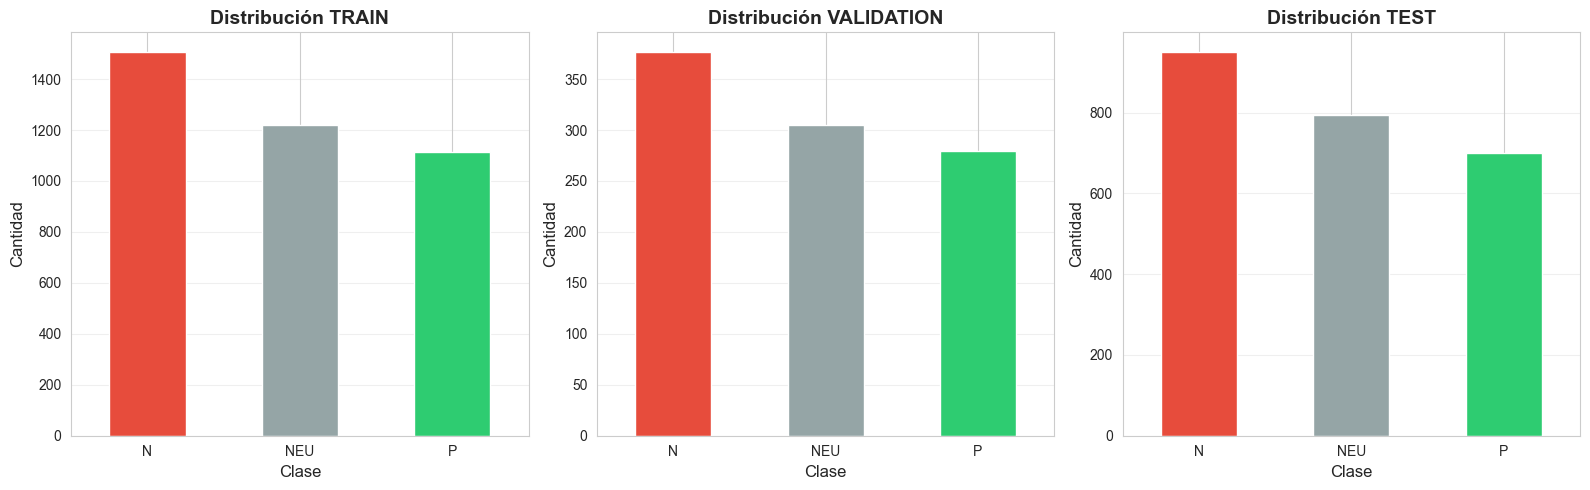


💾 Gráfico guardado en: resultados/distribucion_clases_TASS.png


In [28]:
# Crear gráfico de barras comparativo
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Colores sugeridos (ajustar según tus clases)
colores = {'N': '#e74c3c', 'NEU': '#95a5a6', 'P': '#2ecc71', 
           'NEG': '#e74c3c', 'NEUTRAL': '#95a5a6', 'POS': '#2ecc71'}

# Train
dist_train.plot(kind='bar', ax=axes[0], 
                color=[colores.get(str(x), '#3498db') for x in dist_train.index])
axes[0].set_title('Distribución TRAIN', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Validation
dist_val.plot(kind='bar', ax=axes[1], 
              color=[colores.get(str(x), '#3498db') for x in dist_val.index])
axes[1].set_title('Distribución VALIDATION', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Clase', fontsize=12)
axes[1].set_ylabel('Cantidad', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

# Test
dist_test.plot(kind='bar', ax=axes[2], 
               color=[colores.get(str(x), '#3498db') for x in dist_test.index])
axes[2].set_title('Distribución TEST', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Clase', fontsize=12)
axes[2].set_ylabel('Cantidad', fontsize=12)
axes[2].tick_params(axis='x', rotation=0)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../resultados/fase1_tass/distribucion_clases_TASS.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Gráfico guardado en: resultados/fase1_tass/distribucion_clases_TASS.png")

## 9. Análisis de desbalance de clases

In [29]:
# Calcular ratio de desbalance
def calcular_desbalance(distribucion):
    """Calcula el ratio de desbalance."""
    clase_max = distribucion.max()
    clase_min = distribucion.min()
    ratio = clase_max / clase_min
    return ratio, clase_max, clase_min

print("⚖️ Análisis de desbalance de clases:")
print("="*70)

for nombre, dist in [('TRAIN', dist_train), ('VALIDATION', dist_val), ('TEST', dist_test)]:
    ratio, max_count, min_count = calcular_desbalance(dist)
    print(f"\n{nombre}:")
    print(f"   Clase mayoritaria: {max_count} muestras")
    print(f"   Clase minoritaria: {min_count} muestras")
    print(f"   Ratio de desbalance: {ratio:.2f}x")
    
    if ratio < 1.5:
        print(f"   ✅ Dataset balanceado (ratio < 1.5x)")
    elif ratio < 3:
        print(f"   ⚠️ Desbalance moderado (1.5x ≤ ratio < 3x)")
    else:
        print(f"   ❌ Desbalance significativo (ratio ≥ 3x)")
        print(f"      → Considerar class_weight o técnicas de balanceo")

print("="*70)

⚖️ Análisis de desbalance de clases:

TRAIN:
   Clase mayoritaria: 1508 muestras
   Clase minoritaria: 1115 muestras
   Ratio de desbalance: 1.35x
   ✅ Dataset balanceado (ratio < 1.5x)

VALIDATION:
   Clase mayoritaria: 377 muestras
   Clase minoritaria: 279 muestras
   Ratio de desbalance: 1.35x
   ✅ Dataset balanceado (ratio < 1.5x)

TEST:
   Clase mayoritaria: 951 muestras
   Clase minoritaria: 699 muestras
   Ratio de desbalance: 1.36x
   ✅ Dataset balanceado (ratio < 1.5x)


## 10. Análisis de longitud de textos

In [30]:
# Calcular longitudes (caracteres y palabras)
def calcular_longitudes(df, text_col):
    """Calcula longitudes en caracteres y palabras."""
    df = df.copy()
    df['len_chars'] = df[text_col].astype(str).str.len()
    df['len_words'] = df[text_col].astype(str).str.split().str.len()
    return df

df_train = calcular_longitudes(df_train, TEXT_COL)
df_val = calcular_longitudes(df_val, TEXT_COL)
df_test = calcular_longitudes(df_test, TEXT_COL)

# Estadísticas de longitud
def mostrar_estadisticas_longitud(df, nombre):
    """Muestra estadísticas de longitud de textos."""
    print(f"\n📏 Estadísticas de longitud - {nombre}:")
    print("="*70)
    print("\n📝 Caracteres:")
    print(df['len_chars'].describe().to_string())
    print("\n📝 Palabras:")
    print(df['len_words'].describe().to_string())
    print("="*70)

mostrar_estadisticas_longitud(df_train, "TRAIN")
mostrar_estadisticas_longitud(df_val, "VALIDATION")
mostrar_estadisticas_longitud(df_test, "TEST")


📏 Estadísticas de longitud - TRAIN:

📝 Caracteres:
count    3841.000000
mean       88.746160
std        33.912508
min        18.000000
25%        60.000000
50%        90.000000
75%       120.000000
max       139.000000

📝 Palabras:
count    3841.000000
mean       15.834939
std         6.593189
min         5.000000
25%        10.000000
50%        16.000000
75%        21.000000
max        33.000000

📏 Estadísticas de longitud - VALIDATION:

📝 Caracteres:
count    961.000000
mean      89.041623
std       34.189794
min       19.000000
25%       60.000000
50%       92.000000
75%      121.000000
max      138.000000

📝 Palabras:
count    961.000000
mean      15.851197
std        6.631814
min        5.000000
25%       10.000000
50%       16.000000
75%       22.000000
max       32.000000

📏 Estadísticas de longitud - TEST:

📝 Caracteres:
count    2443.000000
mean       92.469505
std        61.340848
min        17.000000
25%        62.000000
50%        93.000000
75%       126.000000
max      25

## 11. Visualización de distribución de longitudes

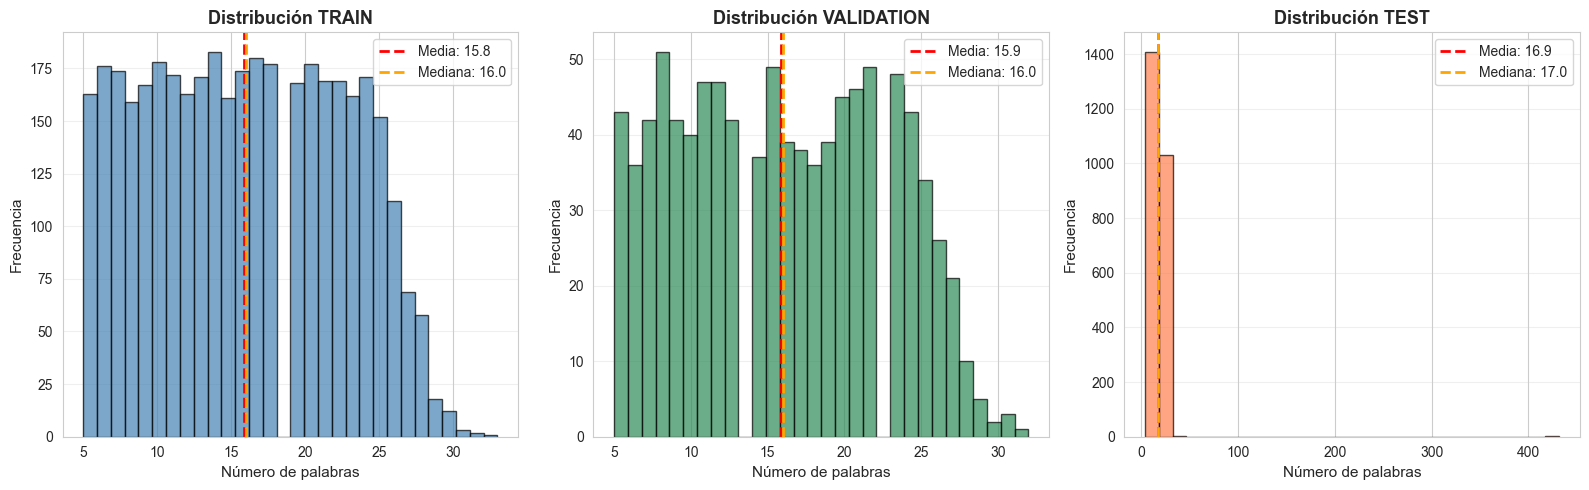


💾 Gráfico guardado en: resultados/distribucion_longitudes_TASS.png


In [31]:
# Histogramas de longitud de palabras
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Train
axes[0].hist(df_train['len_words'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_train['len_words'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Media: {df_train["len_words"].mean():.1f}')
axes[0].axvline(df_train['len_words'].median(), color='orange', linestyle='--', linewidth=2, 
                label=f'Mediana: {df_train["len_words"].median():.1f}')
axes[0].set_title('Distribución TRAIN', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Número de palabras', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Validation
axes[1].hist(df_val['len_words'], bins=30, color='seagreen', edgecolor='black', alpha=0.7)
axes[1].axvline(df_val['len_words'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Media: {df_val["len_words"].mean():.1f}')
axes[1].axvline(df_val['len_words'].median(), color='orange', linestyle='--', linewidth=2, 
                label=f'Mediana: {df_val["len_words"].median():.1f}')
axes[1].set_title('Distribución VALIDATION', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de palabras', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Test
axes[2].hist(df_test['len_words'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[2].axvline(df_test['len_words'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Media: {df_test["len_words"].mean():.1f}')
axes[2].axvline(df_test['len_words'].median(), color='orange', linestyle='--', linewidth=2, 
                label=f'Mediana: {df_test["len_words"].median():.1f}')
axes[2].set_title('Distribución TEST', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Número de palabras', fontsize=11)
axes[2].set_ylabel('Frecuencia', fontsize=11)
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../resultados/fase1_tass/distribucion_longitudes_TASS.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Gráfico guardado en: resultados/fase1_tass/distribucion_longitudes_TASS.png")

## 12. Recomendación de max_length para tokenización

In [32]:
# Calcular percentiles para determinar max_length óptimo
print("📊 Análisis de longitudes para determinar max_length:")
print("="*70)

for nombre, df in [('TRAIN', df_train), ('VALIDATION', df_val), ('TEST', df_test)]:
    print(f"\n{nombre}:")
    for percentil in [75, 90, 95, 99]:
        val = np.percentile(df['len_words'], percentil)
        print(f"   Percentil {percentil:>2}: {val:>6.1f} palabras")

# Recomendación
p95_train = np.percentile(df_train['len_words'], 95)
max_words = df_train['len_words'].max()

print("\n" + "="*70)
print("\n💡 RECOMENDACIÓN para tokenización:")
print(f"   - Percentil 95 (train): {p95_train:.0f} palabras")
print(f"   - Máximo absoluto: {max_words:.0f} palabras")

if p95_train <= 32:
    print(f"\n   ✅ Usar max_length=64 (cubre >95% de tweets)")
elif p95_train <= 64:
    print(f"\n   ✅ Usar max_length=128 (cubre >95% de tweets)")
else:
    print(f"\n   ⚠️ Usar max_length=128 o 256 (tweets muy largos)")

print("\n   📌 Para BERT/BETO: max_length típico = 128 tokens")
print("   📌 Tokens ≈ 1.3 × palabras (aproximado para español)")
print("="*70)

📊 Análisis de longitudes para determinar max_length:

TRAIN:
   Percentil 75:   21.0 palabras
   Percentil 90:   25.0 palabras
   Percentil 95:   26.0 palabras
   Percentil 99:   28.0 palabras

VALIDATION:
   Percentil 75:   22.0 palabras
   Percentil 90:   25.0 palabras
   Percentil 95:   26.0 palabras
   Percentil 99:   29.0 palabras

TEST:
   Percentil 75:   23.0 palabras
   Percentil 90:   27.0 palabras
   Percentil 95:   28.0 palabras
   Percentil 99:   30.0 palabras


💡 RECOMENDACIÓN para tokenización:
   - Percentil 95 (train): 26 palabras
   - Máximo absoluto: 33 palabras

   ✅ Usar max_length=64 (cubre >95% de tweets)

   📌 Para BERT/BETO: max_length típico = 128 tokens
   📌 Tokens ≈ 1.3 × palabras (aproximado para español)


## 13. Longitud por clase

📊 Longitud promedio por clase (palabras):
   Clase      N: Media= 16.40 ±  6.76 | Mediana=  16.5
   Clase    NEU: Media= 15.60 ±  6.54 | Mediana=  16.0
   Clase      P: Media= 15.34 ±  6.38 | Mediana=  15.0


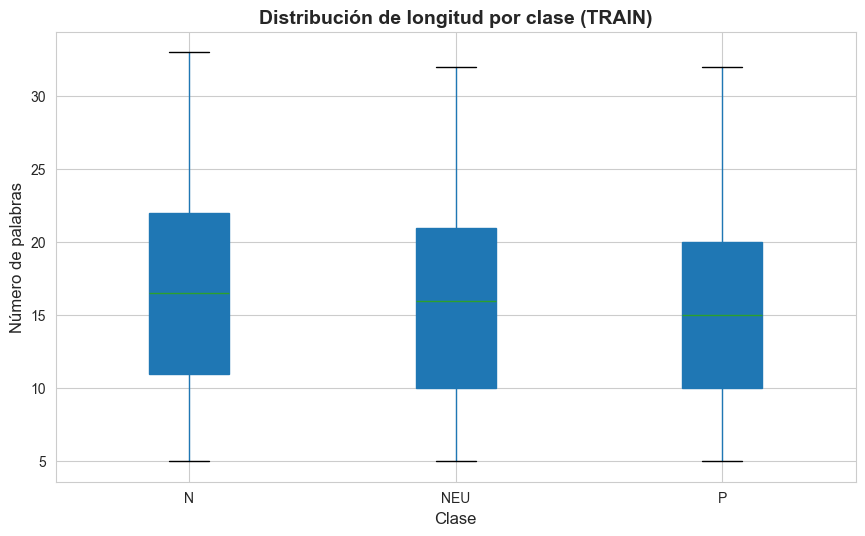


💾 Gráfico guardado en: resultados/longitud_por_clase_TASS.png


In [33]:
# Analizar si hay diferencia de longitud entre clases
print("📊 Longitud promedio por clase (palabras):")
print("="*70)

for clase in sorted(df_train[LABEL_COL].unique()):
    mask = df_train[LABEL_COL] == clase
    media = df_train[mask]['len_words'].mean()
    std = df_train[mask]['len_words'].std()
    mediana = df_train[mask]['len_words'].median()
    print(f"   Clase {str(clase):>6}: Media={media:>6.2f} ± {std:>5.2f} | Mediana={mediana:>6.1f}")

print("="*70)

# Boxplot por clase
plt.figure(figsize=(10, 6))
df_train.boxplot(column='len_words', by=LABEL_COL, ax=plt.gca(), 
                  patch_artist=True, grid=True)
plt.title('Distribución de longitud por clase (TRAIN)', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remover título automático
plt.xlabel('Clase', fontsize=12)
plt.ylabel('Número de palabras', fontsize=12)
plt.savefig('../resultados/fase1_tass/longitud_por_clase_TASS.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Gráfico guardado en: resultados/fase1_tass/longitud_por_clase_TASS.png")

## 14. Ejemplos de tweets por clase

In [34]:
# Mostrar ejemplos representativos de cada clase
print("📝 Ejemplos de tweets por clase:")
print("="*80)

for clase in sorted(df_train[LABEL_COL].unique()):
    print(f"\n🏷️ Clase: {clase}")
    print("-"*80)
    ejemplos = df_train[df_train[LABEL_COL] == clase].sample(
        n=min(3, len(df_train[df_train[LABEL_COL] == clase])), 
        random_state=42
    )
    for i, (idx, row) in enumerate(ejemplos.iterrows(), 1):
        texto = str(row[TEXT_COL])
        print(f"\n   Ejemplo {i}: ({row['len_words']:.0f} palabras)")
        print(f"   {texto[:200]}{'...' if len(texto) > 200 else ''}")

print("\n" + "="*80)

📝 Ejemplos de tweets por clase:

🏷️ Clase: N
--------------------------------------------------------------------------------

   Ejemplo 1: (8 palabras)
   Ahora por floja me voy a dormir tarde

   Ejemplo 2: (22 palabras)
   Tengo tantísimo sueño que cada vez que me levanto y ando me choco con la pared en serio me siento súper gilipollas

   Ejemplo 3: (24 palabras)
   Antes aún follaba para completar el círculo de cosas básicas en la vida pero ahora tengo a Ander a tomar por culo de lejos

🏷️ Clase: NEU
--------------------------------------------------------------------------------

   Ejemplo 1: (8 palabras)
   @gat1tu sólo viste feo... Lo demás todo ok

   Ejemplo 2: (15 palabras)
   #superluna eectativa vs realidad. Gracias • • • • • • • #crc #puravida #costarica…

   Ejemplo 3: (16 palabras)
   Para mi mamá toda la ropa que escojo es fea hasta que me la ve puesta

🏷️ Clase: P
--------------------------------------------------------------------------------

   Ejemplo 1: (26 pal

## 15. Guardar datasets procesados

In [35]:
# Guardar los datasets con los splits creados
print("💾 Guardando datasets procesados...")

# Crear directorio si no existe
import os
os.makedirs('../resultados/fase1_tass', exist_ok=True)

# Guardar CSVs
df_train.to_csv('../resultados/fase1_tass/tass_train.csv', index=False)
df_val.to_csv('../resultados/fase1_tass/tass_validation.csv', index=False)
df_test.to_csv('../resultados/fase1_tass/tass_test.csv', index=False)

print("\n✅ Datasets guardados en carpeta 'resultados/fase1_tass/':")
print(f"   - tass_train.csv: {len(df_train)} muestras")
print(f"   - tass_validation.csv: {len(df_val)} muestras")
print(f"   - tass_test.csv: {len(df_test)} muestras")
print("\n📌 Estos archivos serán usados en el próximo notebook de entrenamiento")

💾 Guardando datasets procesados...

✅ Datasets guardados en carpeta 'resultados/':
   - tass_train.csv: 3841 muestras
   - tass_validation.csv: 961 muestras
   - tass_test.csv: 2443 muestras

📌 Estos archivos serán usados en el próximo notebook de entrenamiento


## 16. Resumen ejecutivo de hallazgos

### 📊 Análisis completado - Dataset TASS 2023

```
DATASET TASS - RESUMEN EJECUTIVO
=====================================================

1. TAMAÑO DE DATASETS:
   - Train: 3,841 muestras (80.0%)
   - Validation: 961 muestras (20.0%)  
   - Test: 2,443 muestras
   - Total: 7,245 muestras

2. DISTRIBUCIÓN DE CLASES (Train):
   - Clase N (Negativo): 39.26% (1,508 muestras)
   - Clase NEU (Neutral): 31.71% (1,218 muestras)
   - Clase P (Positivo): 29.03% (1,115 muestras)
   - Ratio desbalance: 1.35x ✅

3. LONGITUD DE TEXTOS (Train):
   - Media: 15.83 palabras (88.75 caracteres)
   - Mediana: 16.0 palabras (90.0 caracteres)
   - Percentil 95: 26.0 palabras
   - Rango: 5 - 33 palabras
   - Desviación estándar: ±6.59 palabras

4. RECOMENDACIONES PARA ENTRENAMIENTO:
   - max_length sugerido: 64 tokens (cubre >95% tweets)
   - Necesidad de balanceo: NO (ratio 1.35x < 1.5x)
   - Técnicas sugeridas: 
     * Entrenamiento estándar sin técnicas de balanceo
     * Usar BETO/XLM-RoBERTa con max_length=128
     * Considerar data augmentation para clase P (minoritaria)

5. OBSERVACIONES CLAVE:
   - ✅ Dataset bien balanceado entre las 3 clases
   - ✅ Textos cortos típicos de Twitter (media ~16 palabras)
   - ✅ Columnas detectadas: 'sentencia original' (texto), 'label' (etiqueta)
   - ⚠️ Test set tiene outliers (máx 432 palabras) - considerar truncamiento
   - ⚠️ Clase Negativa ligeramente dominante (39% vs 29% Positivo)
   - 📌 Idioma: Español (México) - contiene jerga coloquial
   - 📌 Estratificación exitosa: distribución consistente train/val/test
   
6. ARCHIVOS GENERADOS:
   - resultados/tass_train.csv
   - resultados/tass_validation.csv
   - resultados/tass_test.csv
   - resultados/distribucion_clases_TASS.png
   - resultados/distribucion_longitudes_TASS.png
   - resultados/longitud_por_clase_TASS.png

7. PRÓXIMOS PASOS:
   - Continuar con fine-tuning de XLNet y XLM-RoBERTa
   - Probar batch_size: 8, 16, 32
   - Objetivo: Superar baseline BETO (64% F1-score)
   - Publicar mejores modelos en HuggingFace Hub
=====================================================
```

**✅ ANÁLISIS EXPLORATORIO COMPLETADO**